# MVP — Machine Learning & Analytics

**Nome:** _Carlos André Cordeiro de Oliveira_  
**Matrícula:** _4052026000485_  
**Data:** _01/07/2026_  
**Dataset:** _Predict Students' Dropout and Academic Success._
**Link da fonte:** _https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success_
**Link Raw Github:** _https://raw.githubusercontent.com/literaturaandre-byte/mvp-ml-carlos-oliveira/refs/heads/main/predict%2Bstudents%2Bdropout%2Band%2Bacademic%2Bsuccess.csv_  
**Tipo de problema:** _Classificação_  

---


## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✅ |
| Análise exploratória objetiva, conectada à modelagem | ✅ |
| Divisão adequada em treino/teste e, se aplicável, validação | ✅ |
| Prevenção de vazamento de dados | ✅ |
| Tratamentos de dados justificados | ✅ |
| Pipeline ou sequência reprodutível de pré-processamento | ✅ |
| Modelo baseline definido | ✅ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ✅ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ✅ |
| Avaliação com métricas coerentes com o problema | ✅ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ |
| Código limpo, organizado e executável do início ao fim | ✅ |
| Conclusão conectada ao objetivo inicial | ✅ |

# 1. Definição do problema

## 1.1 Descrição do problema

A evasão no ensino superior é um problema relevante do ponto de vista acadêmico, institucional e social, pois afeta a trajetória dos estudantes, compromete indicadores educacionais e pode sinalizar dificuldades econômicas, pedagógicas ou de integração acadêmica. Neste MVP, o problema tratado é a identificação de estudantes com maior probabilidade de evasão a partir de variáveis demográficas, socioeconômicas e acadêmicas disponíveis em uma base pública.

A solução proposta busca apoiar uma tarefa de classificação, distinguindo estudantes em risco de **Dropout** daqueles classificados como **Non-Dropout**, categoria que agrupa os casos originalmente rotulados como *Graduate* e *Enrolled*. A ideia não é substituir a análise humana, mas oferecer um modelo preditivo inicial que possa servir como ferramenta de apoio à tomada de decisão em contextos educacionais.

Os principais interessados em uma solução desse tipo seriam gestores educacionais, equipes pedagógicas, setores de permanência estudantil e pesquisadores em educação e análise de dados. O problema é relevante sobretudo no setor público da educação porque a identificação antecipada de risco de evasão pode orientar intervenções institucionais mais rápidas e focalizadas, adequar e otimizar políticas públicas de educação, racionalizar o investimento proveniente do orçamento público, contribuindo para permanência, acompanhamento e planejamento acadêmico.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a evasão estudantil a partir de atributos acadêmicos, sociais e institucionais presentes no dataset escolhido, comparando um baseline simples com modelos candidatos mais robustos.

Além do desempenho preditivo, o trabalho busca demonstrar um fluxo completo e reprodutível de um projeto de Machine Learning, incluindo definição do problema, preparação dos dados, treinamento, avaliação crítica dos resultados e discussão de limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** Classificação binária

**Justificativa:**  
Este problema é de classificação porque o modelo deve prever uma categoria discreta para cada estudante. Para simplificar a análise e tornar o MVP mais direto, a variável-alvo original foi transformada em um problema binário: estudantes da classe **Dropout** permanecem como classe positiva, enquanto estudantes originalmente classificados como **Graduate** e **Enrolled** são agrupados na classe **Non-Dropout**.

Essa escolha reduz a complexidade da modelagem e da interpretação das métricas, permitindo avaliar o problema com medidas clássicas de classificação binária, como acurácia, recall, F1-score, matriz de confusão e AUC-ROC. Além disso, essa formulação é coerente com o objetivo prático de identificar risco de evasão, que é o foco principal deste MVP.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Variáveis acadêmicas relacionadas ao desempenho nos semestres, como número de unidades curriculares aprovadas e médias, devem ter relação importante com a evasão.
2. Variáveis administrativas e socioeconômicas, como situação de débito, pagamento em dia das mensalidades e bolsa, também podem contribuir para a previsão.
3. Um modelo supervisionado simples, mas bem estruturado, pode superar claramente um baseline ingênuo e produzir resultados úteis para um MVP inicial.

**Critérios de sucesso:**
- Métrica principal: F1-score para a classe positiva (*Dropout*) e recall para evasão.
- Resultado mínimo esperado: superar o baseline simples de classificação e obter desempenho consistente também nos dados de teste.
- Restrição prática: manter o pipeline simples, reprodutível e interpretável, sem depender de técnicas complexas ou alto custo computacional.

**Premissas e restrições do MVP:**
- O dataset é tratado como uma base tabular supervisionada, adequada para treinamento de modelos de classificação.
- A variável-alvo será binarizada para tornar o problema mais simples e mais aderente ao objetivo de prever evasão.
- Como se trata de um MVP acadêmico, o foco principal não é maximizar performance a qualquer custo, mas construir uma solução coerente, justificável e executável do início ao fim.
- O desempenho do modelo será interpretado dentro das limitações da base utilizada, sem assumir que o resultado se generaliza automaticamente para outros contextos institucionais.

# 2. Ambiente, bibliotecas e reprodutibilidade

Este notebook foi desenvolvido em Python, com execução prevista no Google Colab, utilizando bibliotecas amplamente empregadas em projetos de análise de dados e Machine Learning tabular.

As principais bibliotecas usadas neste MVP são:
- **pandas** e **numpy** para manipulação e transformação dos dados;
- **matplotlib** e **seaborn** para visualizações;
- **scikit-learn** para divisão treino/teste, pré-processamento, construção de pipelines, treinamento, ajuste de hiperparâmetros e avaliação dos modelos.

Para garantir reprodutibilidade, foi definida uma seed fixa, aplicada tanto ao NumPy quanto ao módulo `random`. Como este projeto utiliza dados tabulares e modelos clássicos de Machine Learning, não há necessidade de GPU.


In [31]:
# === Setup básico e reprodutibilidade ===

import os
import sys
import time
import random
import warnings
import io
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)
print("Bibliotecas principais carregadas com sucesso.")

Python: 3.12.13
Seed: 42
Bibliotecas principais carregadas com sucesso.


In [32]:
import pandas as pd
url = "https://raw.githubusercontent.com/literaturaandre-byte/mvp-ml-carlos-oliveira/refs/heads/main/predict%2Bstudents%2Bdropout%2Band%2Bacademic%2Bsuccess.csv"
df = pd.read_csv(url, sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2.1 Dependências adicionais

Neste MVP, não foi necessário instalar dependências adicionais além das bibliotecas já disponíveis no ambiente padrão do Google Colab. Essa decisão ajuda a manter o notebook mais simples de executar.

Como o problema envolve classificação supervisionada em dados tabulares, as bibliotecas padrão do ecossistema Python já são suficientes para as etapas de análise exploratória, pré-processamento, modelagem, ajuste e avaliação.


In [33]:
# Nenhuma dependência adicional foi necessária para este projeto.

## 2.2 Funções auxiliares

Foram definidas algumas funções auxiliares para reduzir repetição de código e deixar o notebook mais organizado. Essas funções serão utilizadas para calcular métricas de classificação, organizar os resultados em tabela e facilitar a comparação entre os modelos.

Como este MVP trata um problema de classificação binária, as métricas priorizadas serão acurácia, precisão, recall, F1-score e ROC AUC, quando houver probabilidades disponíveis.


In [34]:
def evaluate_classification(y_true, y_pred, proba=None):
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def show_results_table(results_dict, sort_by="f1"):
    """
    Converte o dicionário de resultados em DataFrame ordenado.
    """
    results_df = pd.DataFrame(results_dict).T
    if sort_by in results_df.columns:
        results_df = results_df.sort_values(by=sort_by, ascending=False)
    return results_df


def plot_confusion_matrix(model, X_test, y_test, labels=None):
    """
    Exibe a matriz de confusão do modelo.
    """
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=labels,
        cmap="Blues",
        ax=ax
    )
    plt.title("Matriz de confusão")
    plt.show()

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste projeto é **Predict Students' Dropout and Academic Success**, disponibilizado no **UCI Machine Learning Repository**. Para garantir a reprodutibilidade exigida no MVP, o arquivo CSV foi disponibilizado em um repositório público no GitHub e será carregado diretamente no notebook por meio de uma URL pública.

**Fonte original do dataset:**  
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

**Versão utilizada no notebook (URL pública raw no GitHub):**  
https://raw.githubusercontent.com/literaturaandre-byte/mvp-ml-carlos-oliveira/refs/heads/main/predict%2Bstudents%2Bdropout%2Band%2Bacademic%2Bsuccess.csv

A base foi escolhida pelos seguintes motivos: 1. ela trata de um problema real e relevante: a evasão acadêmica; 2. possui tamanho adequado para um MVP, permitindo análise exploratória, treinamento e comparação de modelos sem grande custo computacional; 3. contém variáveis tabulares de natureza acadêmica, social e institucional, o que favorece a construção de um pipeline clássico de Machine Learning.

Do ponto de vista metodológico, esta base também é interessante porque oferece uma variável-alvo originalmente multiclasse (*Dropout*, *Graduate* e *Enrolled*), permitindo adaptar o problema para classificação binária. Neste trabalho, a classe **Dropout** será mantida como classe positiva, enquanto **Graduate** e **Enrolled** serão agrupadas na categoria **Non-Dropout**.

Como se trata de uma base pública e amplamente utilizada para fins acadêmicos, não há restrições de confidencialidade individual impostas pelo uso no notebook. Ainda assim, os resultados devem ser interpretados com cautela, pois a capacidade preditiva observada neste dataset não deve ser generalizada automaticamente para outros contextos institucionais.

## 3.2 Carga dos dados

Nesta etapa, os dados são carregados diretamente a partir de uma URL pública do GitHub, garantindo que o notebook possa ser executado do início ao fim sem upload manual de arquivos.

Como o arquivo CSV utiliza ponto e vírgula como separador, a leitura é feita com `sep=';'`. Após a carga, a variável-alvo original (**Target**) é convertida para uma versão binária, adequada ao problema definido neste MVP.

In [35]:
# === Carga dos dados reais ===

url = "https://raw.githubusercontent.com/literaturaandre-byte/mvp-ml-carlos-oliveira/refs/heads/main/predict%2Bstudents%2Bdropout%2Band%2Bacademic%2Bsuccess.csv"

df = pd.read_csv(url, sep=';')

# Ajuste opcional de nome de coluna com caractere de tabulação
df.columns = [col.strip() for col in df.columns]

# Criação do target binário:
# 1 = Dropout
# 0 = Non-Dropout (Graduate + Enrolled)
df["Target_binary"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

print("Dataset carregado com sucesso.")
print("Formato inicial:", df.shape)
print("\nDistribuição do target original:")
print(df["Target"].value_counts())

print("\nDistribuição do target binário:")
print(df["Target_binary"].value_counts())

df.head()

Dataset carregado com sucesso.
Formato inicial: (4424, 38)

Distribuição do target original:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Distribuição do target binário:
Target_binary
0    3003
1    1421
Name: count, dtype: int64


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_binary
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,0


## 3.3 Visão geral do dataset

Após a carga, o dataset apresenta 4.424 registros e 37 colunas originais. Como parte da adaptação do problema para classificação binária, criei uma coluna adicional chamada `Target_binary`, que será utilizada como variável-alvo na modelagem.

A base contém majoritariamente variáveis numéricas codificadas, além da coluna `Target`, originalmente categórica. Não foram identificados valores ausentes nem registros duplicados na inspeção inicial, o que simplifica a etapa de preparação dos dados. Também não visualizei uma coluna explícita de identificador único do estudante, o que reduz o risco de vazamento por uso indevido de IDs.

A variável-alvo original possui três categorias: **Graduate**, **Dropout** e **Enrolled**. Para tornar o MVP mais direto e mais aderente ao objetivo de prever evasão, essa variável foi transformada em uma classificação binária, na qual **Dropout = 1** e **Non-Dropout = 0**.

In [36]:
# === Visão geral do dataset ===

print("Formato do dataset:", df.shape)

print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

print("\nNúmero de linhas duplicadas:", df.duplicated().sum())

print("\nResumo estatístico das variáveis numéricas:")
display(df.describe().T)

print("\nDistribuição do target original:")
display(
    pd.DataFrame({
        "contagem": df["Target"].value_counts(),
        "percentual (%)": round(df["Target"].value_counts(normalize=True) * 100, 2)
    })
)

print("\nDistribuição do target binário:")
display(
    pd.DataFrame({
        "contagem": df["Target_binary"].value_counts(),
        "percentual (%)": round(df["Target_binary"].value_counts(normalize=True) * 100, 2)
    })
)

Formato do dataset: (4424, 38)

Tipos de dados:


,tipo
Marital status,int64
Application mode,int64
Application order,int64
Course,int64
Daytime/evening attendance,int64
Previous qualification,int64
Previous qualification (grade),float64
Nacionality,int64
Mother's qualification,int64
Father's qualification,int64



Valores ausentes por coluna:


,ausentes
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0



Número de linhas duplicadas: 0

Resumo estatístico das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000



Distribuição do target original:


,contagem,percentual (%)
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95



Distribuição do target binário:


,contagem,percentual (%)
Target_binary,,
0,3003,67.88
1,1421,32.12


### Comentários iniciais sobre a estrutura da base

A inspeção inicial mostra que a base está limpa do ponto de vista de valores ausentes e duplicatas, o que facilita a construção do pipeline. Além disso, a proporção entre as classes da variável `Target_binary` indica um desbalanceamento moderado, já que a classe de evasão representa uma parcela menor do conjunto de dados, mas ainda suficientemente expressiva para treinamento e avaliação dos modelos.

## 3.4 Dicionário de dados

Como o dataset possui muitas colunas, este dicionário resume apenas as variáveis mais importantes para a compreensão do problema.

| Coluna | Tipo | Descrição | Uso no modelo |
|---|---|---|---|
| `Target` | categórica | Situação acadêmica original (`Dropout`, `Graduate`, `Enrolled`) | Não |
| `Target_binary` | binária | Alvo do MVP (`1 = Dropout`, `0 = Non-Dropout`) | Sim |
| `Age at enrollment` | numérica | Idade no ingresso | Sim |
| `Admission grade` | numérica | Nota de admissão | Sim |
| `Previous qualification (grade)` | numérica | Nota da formação anterior | Sim |
| `Debtor` | categórica codificada | Indica débito | Sim |
| `Tuition fees up to date` | categórica codificada | Indica pagamento em dia | Sim |
| `Curricular units 1st sem (...)` | grupo de variáveis | Indicadores de desempenho no 1º semestre | Sim |
| `Curricular units 2nd sem (...)` | grupo de variáveis | Indicadores de desempenho no 2º semestre | Sim |
| `Unemployment rate`, `Inflation rate`, `GDP` | numéricas | Variáveis macroeconômicas contextuais | Sim |

# 4. Análise exploratória dos dados (EDA)

A análise exploratória a seguir tem como objetivo compreender melhor a distribuição da variável-alvo, identificar padrões iniciais nas variáveis explicativas e levantar hipóteses úteis para a etapa de modelagem.

Como este MVP está centrado em um problema de classificação binária, a EDA será orientada principalmente por três perguntas:
1. A variável-alvo está balanceada ou desbalanceada?
2. Quais atributos parecem mais associados à evasão?
3. Há indícios de que certas transformações ou cuidados de pré-processamento serão necessários?

In [37]:
# Configurações visuais
sns.set(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

## 4.1 Distribuição da variável-alvo

O primeiro passo foi a verificação da distribuição da variável-alvo binária, já que o balanceamento entre as classes influencia diretamente a escolha das métricas e a interpretação do desempenho dos modelos.

Em problemas de evasão, é importante observar se a classe positiva (**Dropout**) é minoritária, pois isso pode exigir maior atenção a métricas como recall e F1-score, e não apenas à acurácia.

,contagem,percentual (%)
Target_binary,,
0,3003,67.88
1,1421,32.12


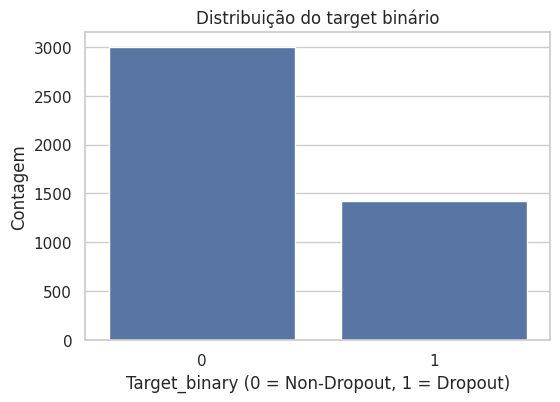

In [38]:
# Distribuição do target binário
target_dist = pd.DataFrame({
    "contagem": df["Target_binary"].value_counts().sort_index(),
    "percentual (%)": round(df["Target_binary"].value_counts(normalize=True).sort_index() * 100, 2)
})

display(target_dist)

# Gráfico
plt.figure(figsize=(6, 4))
sns.countplot(x="Target_binary", data=df)
plt.title("Distribuição do target binário")
plt.xlabel("Target_binary (0 = Non-Dropout, 1 = Dropout)")
plt.ylabel("Contagem")
plt.show()

A distribuição mostra que a classe **Non-Dropout** é majoritária, enquanto a classe **Dropout** representa uma parcela menor da base. Ainda assim, o desbalanceamento não é extremo, o que torna viável trabalhar inicialmente com modelos supervisionados clássicos sem recorrer obrigatoriamente a técnicas mais avançadas de reamostragem.

Esse resultado sugere que a avaliação dos modelos deve dar atenção especial à capacidade de identificar corretamente os casos de evasão, já que uma acurácia aparentemente alta pode mascarar desempenho fraco sobre a classe positiva.

## 4.2 Estatísticas descritivas iniciais

Nesta etapa, são examinadas estatísticas descritivas das variáveis numéricas para identificar escalas distintas, dispersão, possíveis extremos e sinais iniciais de heterogeneidade entre os atributos.

Essa inspeção é importante porque modelos como regressão logística são sensíveis à escala das variáveis, o que reforça a necessidade posterior de padronização no pipeline.

In [39]:
# Estatísticas descritivas das variáveis numéricas
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


## 4.3 Distribuição de variáveis relevantes

A seguir, são observadas algumas variáveis que, por sua natureza, parecem potencialmente relevantes para a previsão de evasão. Foram priorizados atributos ligados à idade de ingresso, desempenho acadêmico e histórico de entrada no curso.

O objetivo aqui não é esgotar todas as colunas da base, mas identificar sinais iniciais de separação entre estudantes com e sem evasão.

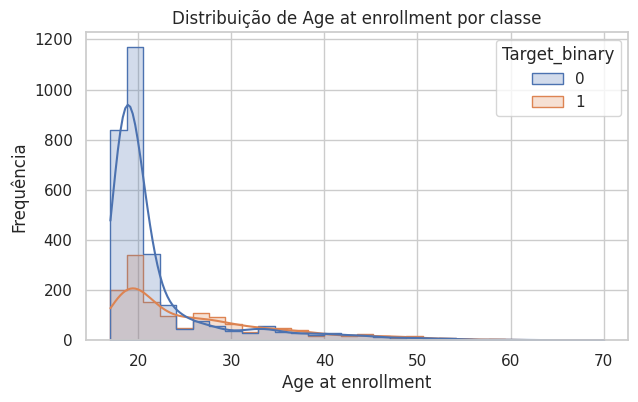

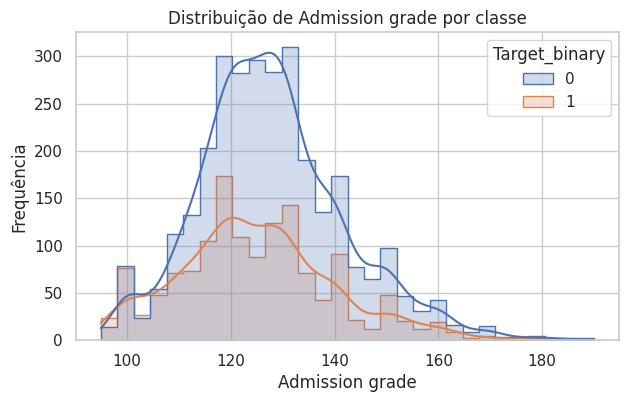

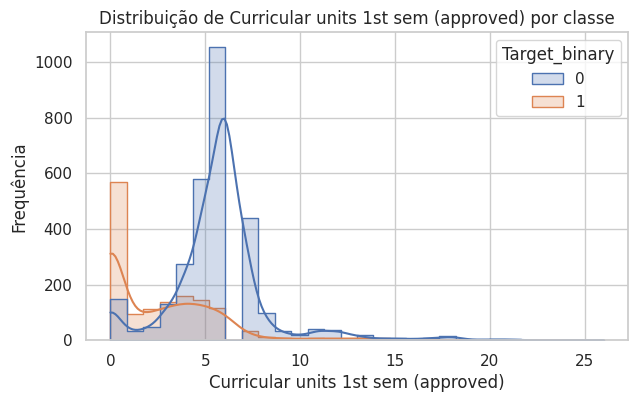

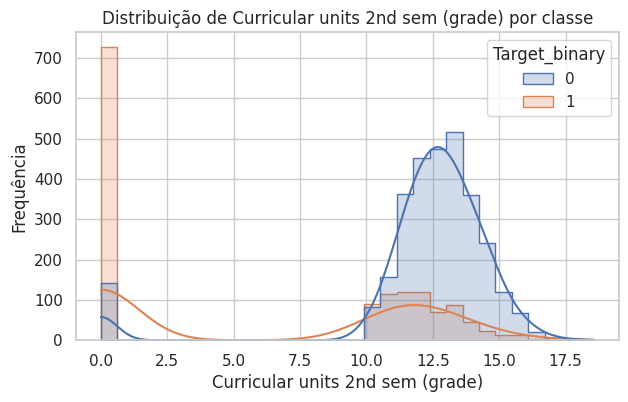

In [40]:
selected_cols = [
    "Age at enrollment",
    "Admission grade",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (grade)"
]

for col in selected_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue="Target_binary", kde=True, bins=30, element="step")
    plt.title(f"Distribuição de {col} por classe")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

Os gráficos permitem observar que algumas variáveis acadêmicas parecem distinguir melhor os grupos do que variáveis mais gerais. Em especial, atributos ligados ao desempenho no primeiro e no segundo semestre tendem a apresentar separação mais visível entre casos de evasão e não evasão.

Isso pode sugerir que o bloco de variáveis acadêmicas pode ter papel central na modelagem, especialmente aquelas relacionadas a aprovação, número de avaliações e médias semestrais.

## 4.4 Relação entre variáveis numéricas e o target

Essa análise não visa estabelecer causalidade, mas ajudar a identificar atributos potencialmente informativos para os modelos, investigando a associação inicial entre variáveis numéricas e a evasão e observando sua correlação com a variável-alvo binária.

Como várias variáveis da base são categorias codificadas numericamente, a correlação deve ser interpretada com cautela. Pode ajudar como ponto de partida para selecionar variáveis mais promissoras e compreender a estrutura geral dos dados.

,correlação com Target_binary
Target_binary,1.000000
Age at enrollment,0.254215
Debtor,0.229407
Gender,0.203983
Application mode,0.198458
Marital status,0.093712
Curricular units 2nd sem (without evaluations),0.079901
Mother's qualification,0.064958
Curricular units 1st sem (without evaluations),0.054230
Previous qualification,0.049379


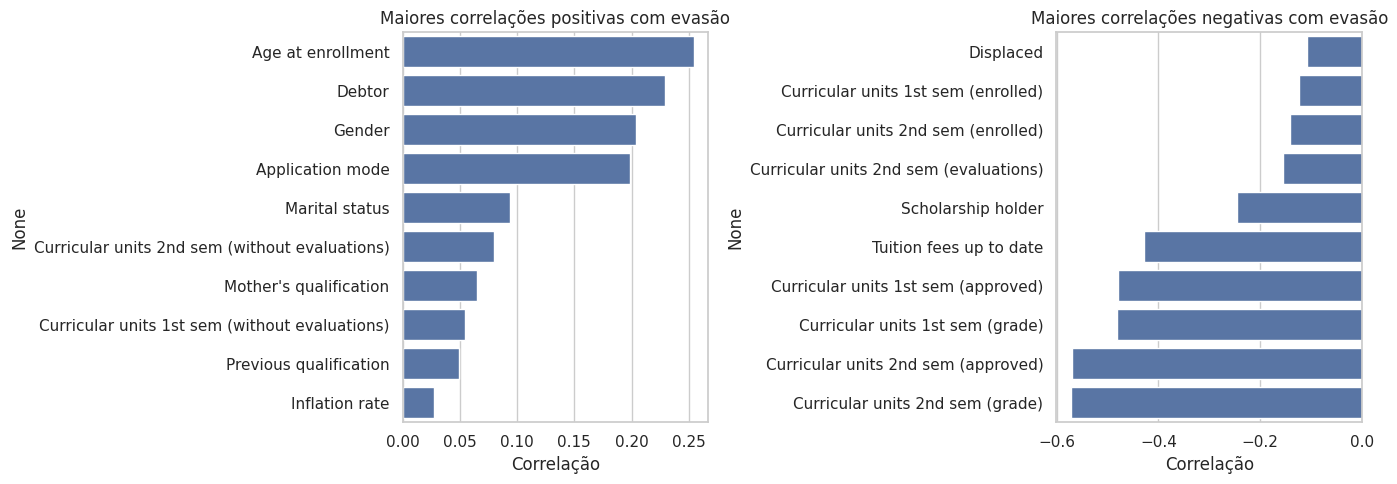

In [41]:
# Correlação das variáveis numéricas com o target binário
corr_with_target = df.select_dtypes(include=np.number).corr()["Target_binary"].sort_values(ascending=False)

display(corr_with_target.to_frame("correlação com Target_binary"))

# Top correlações positivas e negativas (sem contar o próprio target)
top_pos = corr_with_target.drop("Target_binary").head(10)
top_neg = corr_with_target.drop("Target_binary").tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0])
axes[0].set_title("Maiores correlações positivas com evasão")
axes[0].set_xlabel("Correlação")

sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1])
axes[1].set_title("Maiores correlações negativas com evasão")
axes[1].set_xlabel("Correlação")

plt.tight_layout()
plt.show()

Os resultados parecem indicar que variáveis como **Age at enrollment**, **Debtor** e alguns indicadores administrativos apresentam associação positiva com a evasão. Por outro lado, variáveis de desempenho acadêmico, especialmente aprovação e nota no primeiro e no segundo semestre, além de **Tuition fees up to date**, apresentam associação negativa mais forte com `Target_binary`.

Esse padrão é coerente com a lógica substantiva do problema: estudantes com pior desempenho acadêmico e maior fragilidade administrativa ou financeira tendem a apresentar maior risco de evasão. Para a modelagem, isso sugere que tanto atributos acadêmicos quanto variáveis institucionais devem ser preservados no pipeline.

## 4.5 Comparação por classe em variáveis selecionadas

Além das distribuições, é útil comparar diretamente algumas variáveis entre os grupos de evasão e não evasão. Os boxplots ajudam a visualizar diferenças de mediana, dispersão e possíveis outliers.

Essa etapa contribui para avaliar se a separação entre classes parece suficientemente informativa para justificar o uso de modelos supervisionados.

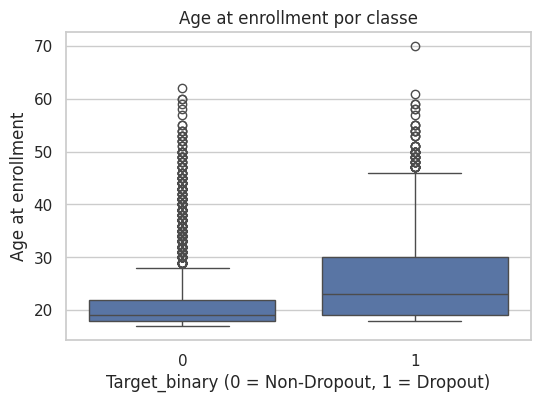

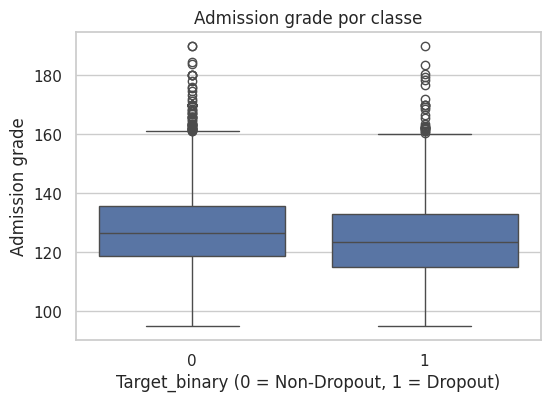

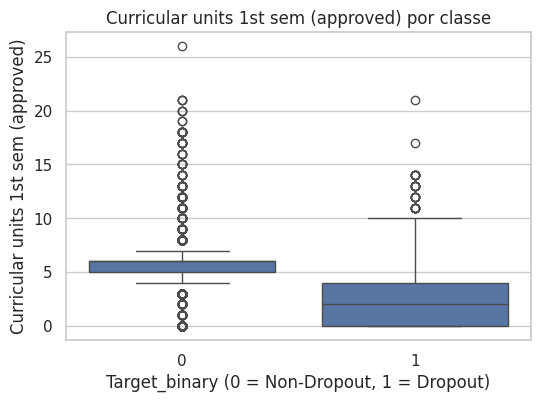

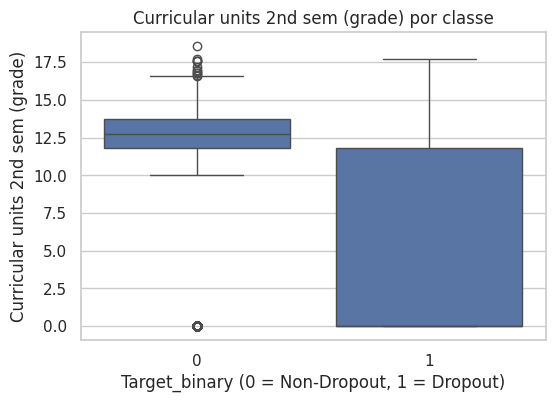

In [42]:
boxplot_cols = [
    "Age at enrollment",
    "Admission grade",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (grade)"
]

for col in boxplot_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Target_binary", y=col)
    plt.title(f"{col} por classe")
    plt.xlabel("Target_binary (0 = Non-Dropout, 1 = Dropout)")
    plt.ylabel(col)
    plt.show()

Os boxplots parecem reforçar a ideia que variáveis de desempenho acadêmico  diferenciam melhor os grupos do que variáveis mais genéricas. Em geral, estudantes classificados como evasão tendem a apresentar menor aprovação e menores médias semestrais, enquanto a idade de ingresso também mostra alguma diferença entre os grupos.

Ao mesmo tempo, a presença de dispersão e sobreposição entre classes indica que o problema não é trivial, o que justifica comparar abordagens de modelagem distintas em vez de assumir que uma regra simples será suficiente.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defini o alvo do problema, o conjunto de atributos preditores e a estratégia de separação entre treino e teste. Como o objetivo deste MVP é prever evasão acadêmica em um cenário supervisionado, foi necessário isolar corretamente a variável-alvo e evitar que informações indevidas vazem para o processo de treinamento.

Como a análise exploratória indicou desbalanceamento moderado entre as classes, a divisão será feita com estratificação, de modo a preservar aproximadamente a mesma proporção de evasão e não evasão nos conjuntos de treino e teste.

## 5.1 Definição do target, features e colunas excluídas

O problema foi formulado como classificação binária, em que a variável-alvo é `Target_binary`, definida como:

- `1 = Dropout`
- `0 = Non-Dropout`

A coluna `Target`, que contém a classe original em três categorias, não será usada como atributo preditor, pois ela foi a base para construir a variável-alvo binária e sua inclusão no modelo geraria vazamento de dados. Não foram identificadas colunas de ID ou data que precisassem ser removidas nesta etapa.

In [43]:
# === Configuração do problema ===

TARGET = "Target_binary"
PROBLEM_TYPE = "classificacao"

ID_COLUMNS = []
DROP_COLUMNS = ["Target"]  # removida para evitar vazamento, já que originou o target binário

assert TARGET in df.columns, "A variável-alvo não foi encontrada no dataframe."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS + [TARGET])
features = [col for col in df.columns if col not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("\nPrimeiras 10 features:")
print(features[:10])

Tipo de problema: classificacao
Target: Target_binary
Número de features: 36

Primeiras 10 features:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification"]


## 5.2 Separação entre variáveis preditoras e variável-alvo

Após a definição das colunas elegíveis, os dados são separados em:
- `X`: conjunto de variáveis preditoras;
- `y`: variável-alvo binária.

Essa separação é para organizar corretamente o pipeline supervisionado e garantir clareza nas etapas seguintes de treino, teste e avaliação.

In [44]:
# Separação entre preditores e alvo
X = df[features].copy()
y = df[TARGET].copy()

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

display(X.head())
display(y.head())

Formato de X: (4424, 36)
Formato de y: (4424,)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


,Target_binary
0,1
1,0
2,1
3,0
4,0


## 5.3 Divisão treino/teste

Como este é um problema de classificação supervisionada com base tabular e sem dimensão temporal, foi adotada uma estratégia de **holdout** com divisão entre treino e teste. O conjunto de treino será usado para ajuste dos modelos e das transformações do pipeline, enquanto o conjunto de teste será reservado para avaliação final em dados não vistos.

A divisão foi feita com `test_size = 0.2`, o que preserva uma amostra suficientemente grande para teste sem comprometer a quantidade de dados disponíveis para treinamento. Também foi utilizada **estratificação**, para manter proporções semelhantes das classes em ambos os conjuntos.

In [45]:
# === Divisão treino/teste ===

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste :", X_test.shape, y_test.shape)

Treino: (3539, 36) (3539,)
Teste : (885, 36) (885,)


## 5.4 Verificação da distribuição das classes após a divisão

Depois da separação, é importante verificar se a estratificação preservou adequadamente a distribuição da variável-alvo nos conjuntos de treino e teste. Essa checagem ajuda a confirmar que a avaliação posterior será mais consistente e comparável.

In [46]:
# Verificação da distribuição das classes
train_dist = y_train.value_counts(normalize=True).sort_index() * 100
test_dist = y_test.value_counts(normalize=True).sort_index() * 100
full_dist = y.value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({
    "Base completa (%)": full_dist.round(2),
    "Treino (%)": train_dist.round(2),
    "Teste (%)": test_dist.round(2)
})

display(dist_df)

,Base completa (%),Treino (%),Teste (%)
Target_binary,,,
0,67.88,67.87,67.91
1,32.12,32.13,32.09


## 5.1 Justificativa da divisão

Para este MVP, optei por uma divisão holdout estratificada, com 80% dos dados para treino e 20% para teste. Como a base tem tamanho razoável, essa escolha permite reservar um conjunto final para avaliação sem comprometer o volume de dados disponível para treinar os modelos.

A estratificação foi importante porque a variável-alvo não está perfeitamente balanceada. Ao preservar proporções semelhantes de evasão e não evasão em treino e teste, a comparação entre os modelos fica mais estável e a avaliação final mais confiável.

Também houve cuidado com vazamento de dados. A coluna `Target`, que deu origem ao `Target_binary`, foi retirada do conjunto de atributos preditores. Além disso, as transformações de pré-processamento não foram ajustadas antecipadamente sobre a base inteira, mas serão aprendidas apenas com os dados de treino dentro do pipeline.

Neste momento, não usei validação cruzada porque a estratégia holdout já atende bem à proposta do MVP e mantém a estrutura do notebook mais simples. Mais adiante, no ajuste de hiperparâmetros, a validação cruzada poderá ser incorporada de forma pontual, quando isso realmente agregar à análise.

# 6. Pré-processamento e pipeline

Nesta etapa, é construída uma sequência reprodutível de transformação dos dados, organizada por meio de `Pipeline` e `ColumnTransformer`. Essa estratégia permite aplicar o pré-processamento de forma controlada, evitando vazamento de dados e mantendo o fluxo de treino e teste consistente.

Como o dataset possui muitas variáveis codificadas numericamente, mas nem todas representam quantidades contínuas, foi feita uma separação manual entre atributos numéricos e atributos categóricos codificados. Essa escolha me pareceu metodologicamente mais adequada do que tratar todas as colunas inteiras como variáveis quantitativas.

## 6.1 Identificação dos tipos de atributos para o pipeline

As variáveis foram divididas em dois grupos principais:

- **Variáveis categóricas codificadas**: colunas que aparecem numericamente na base, mas representam categorias, estados ou indicadores binários;
- **Variáveis numéricas**: colunas que representam medidas, contagens, notas ou indicadores contínuos.

Essa separação será usada para definir transformações específicas para cada grupo dentro do pipeline.

In [47]:
# === Identificação manual de colunas categóricas codificadas ===

categorical_cols = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Número de colunas categóricas:", len(categorical_cols))
print("Número de colunas numéricas:", len(numeric_cols))

print("\nColunas categóricas:")
print(categorical_cols)

print("\nPrimeiras colunas numéricas:")
print(numeric_cols[:10])

Número de colunas categóricas: 18
Número de colunas numéricas: 18

Colunas categóricas:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

Primeiras colunas numéricas:
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)']


## 6.2 Construção do pré-processamento

Para as variáveis numéricas, foi adotada imputação pela mediana e padronização com `StandardScaler`. A padronização é principalmente para modelos lineares, como a regressão logística, pois ajuda a colocar atributos em escalas comparáveis.

Para as variáveis categóricas codificadas, foi adotada imputação pela categoria mais frequente e codificação `OneHotEncoder`, com `handle_unknown="ignore"`. Essa escolha permite representar adequadamente categorias sem impor artificialmente uma ordem numérica entre seus valores.

Embora a base não apresente valores ausentes na inspeção inicial, a inclusão da imputação no pipeline aumenta a robustez do fluxo e mantém o notebook reprodutível.

In [48]:
# === Pipelines de pré-processamento ===

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)

print("Pré-processamento configurado com sucesso.")

Pré-processamento configurado com sucesso.


## 6.3 Verificação do pipeline de transformação

Checagem para confirmar que a separação entre colunas numéricas e categóricas foi feita de forma consistente.

In [49]:
# Teste rápido do pré-processamento
X_train_transformed = preprocess.fit_transform(X_train)
X_test_transformed = preprocess.transform(X_test)

print("Shape de X_train após transformação:", X_train_transformed.shape)
print("Shape de X_test após transformação:", X_test_transformed.shape)

Shape de X_train após transformação: (3539, 250)
Shape de X_test após transformação: (885, 250)


## 6.4 Decisões de pré-processamento

Nesta etapa, o ponto mais importante foi evitar tratar todas as colunas numéricas da mesma forma. Embora muitas variáveis apareçam como números na base, várias delas representam categorias codificadas, como curso, gênero, nacionalidade, situação de débito e bolsa. Por isso, em vez de assumir automaticamente que tudo o que é inteiro é quantitativo, foi feita uma separação manual entre variáveis numéricas e variáveis categóricas codificadas.

Para as variáveis numéricas, optei por usar imputação pela mediana e padronização com `StandardScaler`. A imputação foi mantida por robustez, mesmo sem valores ausentes na inspeção inicial, e a padronização ajuda principalmente modelos mais sensíveis à escala, como a regressão logística.

Para as variáveis categóricas codificadas, a escolha foi imputação pela categoria mais frequente e transformação com `OneHotEncoder`. Essa decisão evita que códigos numéricos sejam interpretados como se tivessem distância ou ordem natural entre si, o que poderia introduzir ruído na modelagem.

Também procurei manter todo o tratamento dentro do pipeline. Isso é importante porque garante que as transformações sejam aprendidas apenas nos dados de treino e depois aplicadas ao teste, reduzindo o risco de vazamento de dados e deixando o fluxo mais limpo, reprodutível e consistente com o objetivo do MVP.

# 7. Baseline e modelos candidatos

Com o pipeline de pré-processamento definido, o próximo passo foi treinar modelos de classificação e comparar seus desempenhos de forma estruturada. A ideia foi verificar se os modelos escolhidos conseguem superar de forma consistente um baseline simples.

Para este MVP, comparei três abordagens: um baseline ingênuo, uma Regressão Logística e uma Random Forest. Essa combinação permitiu contrastar um modelo linear mais interpretável com um modelo baseado em árvores, mais flexível para capturar relações não lineares entre as variáveis.

## 7.1 Justificativa dos modelos escolhidos

O primeiro modelo escolhido foi um baseline com `DummyClassifier`, que sempre prevê a classe majoritária. Esse tipo de baseline é importante porque cria uma referência mínima: se um modelo supervisionado não consegue superá-lo, então ele provavelmente não está aprendendo padrões úteis.

Em seguida, foi utilizada a Regressão Logística, que costuma ser uma escolha forte para problemas de classificação binária com dados tabulares. Funciona bem quando o pré-processamento é feito corretamente e oferece uma base sólida de comparação.

Por fim, escolhi a Random Forest, por ser um modelo mais flexível e capaz de capturar interações e não linearidades entre os atributos. Como a análise exploratória indicou relações possivelmente complexas entre desempenho acadêmico, fatores administrativos e evasão, fez sentido comparar uma abordagem linear com outra baseada em árvores.

## 7.2 Montagem dos pipelines com os modelos

Cada modelo será treinado dentro de um pipeline completo, combinando o pré-processamento definido anteriormente com o estimador final. Essa organização ajuda a manter o fluxo mais limpo, reproduzível e seguro contra vazamento de dados.

In [50]:
# === Modelos candidatos ===

models = {
    "baseline": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    )
}

model_pipelines = {
    name: Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    for name, model in models.items()
}

print("Pipelines dos modelos configurados com sucesso.")

Pipelines dos modelos configurados com sucesso.


## 7.3 Treinamento e avaliação inicial

Os modelos foram treinados com os dados de treino e avaliados no conjunto de teste reservado anteriormente. Como este é um problema de classificação binária com desbalanceamento moderado, foram observadas três métricas principais:

- **Accuracy**, para visão geral de acertos;
- **F1-score ponderado**, para levar em conta o equilíbrio entre precisão e recall;
- **ROC AUC**, para avaliar a capacidade de separação entre as classes.

Também foi registrado o tempo aproximado de treino, apenas como referência prática.

In [51]:
# === Treinamento e avaliação dos modelos ===

results = {}

for name, pipe in model_pipelines.items():
    start_time = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = pipe.predict(X_test)

    y_proba = None
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)

    metrics = evaluate_classification(y_test, y_pred, y_proba)
    metrics["train_time_s"] = round(train_time, 3)

    results[name] = metrics

results_df = show_results_table(results)
display(results_df)

,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.679096,0.549309,0.500000,0.055
LogisticRegression,0.890395,0.888077,0.931528,0.338
RandomForest,0.883616,0.880085,0.927814,3.809


## 7.4 Interpretação dos resultados iniciais

Os resultados iniciais mostram que os dois modelos supervisionados superaram com folga o baseline, o que indica que há sinal preditivo real na base de dados. O baseline, como esperado, teve desempenho limitado e serviu apenas como referência mínima de comparação.

A Regressão Logística apresentou o melhor desempenho geral nesta primeira rodada, com acurácia próxima de 0.89, F1-score ponderado também próximo de 0.89 e ROC AUC acima de 0.93. A Random Forest teve desempenho muito próximo, mas ficou ligeiramente abaixo em todas as métricas principais.

Esse resultado sugere que, pelo menos nesta configuração inicial, as relações presentes nos dados já podem ser bem capturadas por um modelo linear bem pré-processado. Ao mesmo tempo, a proximidade entre os resultados da Regressão Logística e da Random Forest indica que vale a pena levar ambos para uma etapa posterior de avaliação mais detalhada e ajuste de hiperparâmetros.

## 7.5 Comparação visual dos modelos

Para facilitar a comparação entre os modelos, a seguir são exibidos gráficos simples com as métricas principais obtidas no conjunto de teste.

Colunas disponíveis em results_df: ['accuracy', 'f1_weighted', 'roc_auc', 'train_time_s']


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.679096,0.549309,0.500000,0.055
LogisticRegression,0.890395,0.888077,0.931528,0.338
RandomForest,0.883616,0.880085,0.927814,3.809


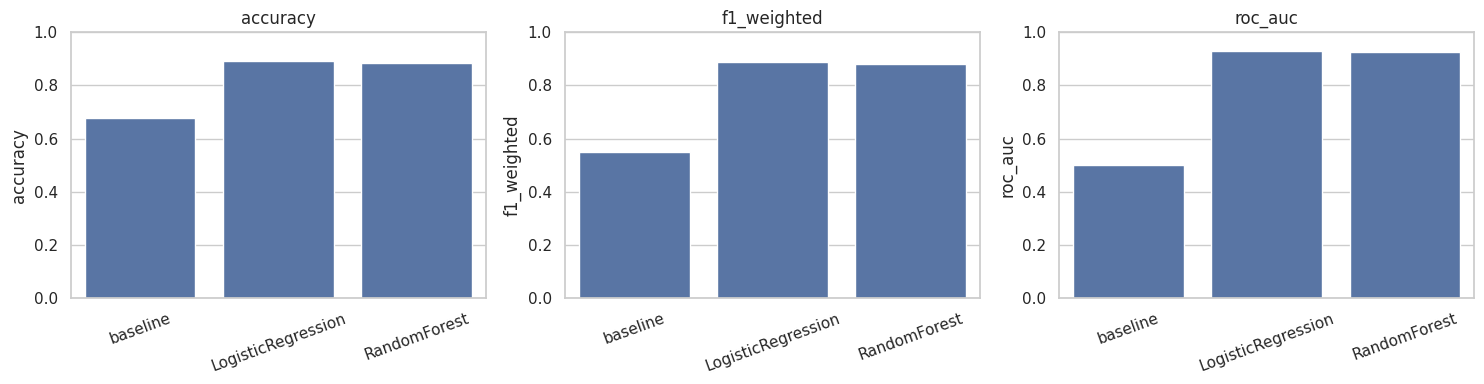

In [52]:
# Gráficos comparativos
print("Colunas disponíveis em results_df:", results_df.columns.tolist())
display(results_df)

plot_df = results_df.copy()

plot_df = plot_df.rename(columns={
    "F1": "f1_weighted",
    "f1": "f1_weighted",
    "f1_score": "f1_weighted",
    "F1-score": "f1_weighted"
})

metrics_to_plot = [col for col in ["accuracy", "f1_weighted", "roc_auc"] if col in plot_df.columns]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 4))

if len(metrics_to_plot) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(x=plot_df.index, y=plot_df[metric], ax=ax)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 7.6 Escolha dos modelos para aprofundamento

Com base nos resultados iniciais, a Regressão Logística e a Random Forest serão mantidas para as próximas etapas do MVP. O baseline cumpriu seu papel como referência mínima, mas não será aprofundado, já que seu objetivo era apenas mostrar o desempenho de uma estratégia ingênua.

A Regressão Logística se destacou por apresentar o melhor resultado geral, além de ser um modelo mais simples e interpretável. A Random Forest, por sua vez, continua relevante porque oferece uma abordagem diferente, capaz de capturar padrões não lineares e interações que o modelo linear pode não explorar totalmente.

Assim, a etapa seguinte fará sentido ao aprofundar principalmente a comparação entre esses dois modelos, avaliando com mais detalhe seu comportamento e, se necessário, realizando ajuste de hiperparâmetros em pelo menos um deles.

# 8. Ajuste de hiperparâmetros e avaliação detalhada

Depois da comparação inicial entre os modelos, explorei a análise sobre pelo menos uma das abordagens testadas. Nesta etapa, o foco será o ajuste de hiperparâmetros da Random Forest, buscando verificar se uma configuração mais adequada consegue melhorar seu desempenho em relação à versão padrão.

A escolha desse modelo para ajuste foi motivada pelo fato de que ele já apresentou bom desempenho na etapa anterior e possui vários hiperparâmetros que influenciam diretamente sua capacidade de generalização, profundidade, complexidade e estabilidade.

## 8.1 Escolha do modelo para ajuste

A Random Forest foi escolhida para a etapa de ajuste porque apresentou desempenho competitivo na comparação inicial e, ao mesmo tempo, oferece espaço real para refinamento. Diferentemente da Regressão Logística, cuja configuração inicial já costuma ser bastante estável, a Random Forest depende mais fortemente de parâmetros como número de árvores, profundidade máxima e critérios mínimos de divisão. Ajustar esse modelo é uma escolha metodologicamente coerente e alinhada ao objetivo do MVP, que é comparar abordagens e explorar ao menos um refinamento adicional de forma controlada.

## 8.2 Estratégia de ajuste

Para ajustar a Random Forest, foi utilizada uma busca aleatória com `RandomizedSearchCV`. Essa escolha é adequada para este MVP porque permite explorar diferentes combinações de hiperparâmetros com custo computacional menor do que uma busca exaustiva em grade. A validação cruzada foi feita com `StratifiedKFold`, preservando a proporção entre as classes em cada partição. Como a tarefa é uma classificação binária com foco em boa capacidade de separação entre evasão e não evasão, a métrica escolhida para orientar a busca foi o **ROC AUC**.

In [ ]:
# === Ajuste de hiperparâmetros da Random Forest ===

rf_tuned_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": randint(100, 251),
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": randint(2, 8),
    "model__min_samples_leaf": randint(1, 4),
    "model__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=rf_tuned_pipe,
    param_distributions=param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
print(random_search.best_params_)
print("\nMelhor ROC AUC médio na validação cruzada:")
print(round(random_search.best_score_, 4))

## 8.3 Melhor configuração encontrada

A busca aleatória retornou a melhor combinação de hiperparâmetros entre as amostras testadas. A partir desse ponto, o melhor estimador encontrado passa a ser avaliado diretamente no conjunto de teste, permitindo verificar se o ganho observado na validação cruzada também se sustenta em dados não vistos.

In [ ]:
best_rf_model = random_search.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_test)
y_proba_rf_tuned = best_rf_model.predict_proba(X_test)

rf_tuned_metrics = evaluate_classification(y_test, y_pred_rf_tuned, y_proba_rf_tuned)
rf_tuned_metrics

## 8.4 Avaliação detalhada no conjunto de teste

Depois do ajuste, o modelo foi avaliado no conjunto de teste com mais detalhe. Além das métricas globais, foram observadas a matriz de confusão e o relatório de classificação, para entender melhor como o modelo se comporta em cada classe.

In [ ]:
print("Métricas do modelo ajustado no teste:")
display(pd.DataFrame(rf_tuned_metrics, index=["RandomForest_tuned"]).T)

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_rf_tuned, digits=4))

ConfusionMatrixDisplay.from_estimator(best_rf_model, X_test, y_test)
plt.title("Matriz de confusão - Random Forest ajustada")
plt.show()

## 8.5 Interpretação dos resultados

A melhor configuração encontrada para a Random Forest utilizou profundidade máxima de 30, `max_features='sqrt'`, `min_samples_leaf=2`, `min_samples_split=6` e 101 árvores. Na validação cruzada, essa configuração alcançou ROC AUC médio em torno de 0.912, indicando desempenho consistente durante o processo de busca.

No conjunto de teste, o modelo ajustado obteve acurácia próxima de 0.878, F1-score ponderado em torno de 0.874 e ROC AUC de aproximadamente 0.930. Isso mostra que a Random Forest ajustada manteve boa capacidade de separação entre as classes e um desempenho geral bastante competitivo.

Observando o relatório de classificação, nota-se que a classe **Non-Dropout** foi identificada com desempenho mais alto, enquanto a classe **Dropout** apresentou recall mais modesto, em torno de 0.715. Em termos práticos, isso significa que o modelo ainda deixa escapar parte dos casos de evasão, o que é relevante do ponto de vista institucional, já que esses são justamente os estudantes de maior interesse para intervenção.

## 8.6 Comparação com a versão sem ajuste

Comparando com a Random Forest utilizada na etapa anterior, o ajuste de hiperparâmetros não produziu um salto expressivo nas métricas finais de teste. Isso sugere que o modelo padrão já estava relativamente bem configurado para este problema, e que o principal ganho do ajuste esteve mais na validação sistemática da abordagem do que em uma melhora substancial de desempenho.

Esse resultado também é útil do ponto de vista analítico: mostra que nem sempre aumentar a complexidade do processo leva a avanços relevantes. Em alguns casos, um modelo mais simples ou já bem ajustado por padrão pode entregar desempenho comparável, com menor custo de experimentação.

# 9. Validação e otimização de hiperparâmetros

Nesta etapa, foi realizada uma busca simples de hiperparâmetros para um dos modelos candidatos, com o objetivo de verificar se uma pequena otimização poderia melhorar ou confirmar o desempenho observado anteriormente. Para o MVP, a escolha foi manter a busca enxuta, com custo computacional controlado, mas ainda suficientemente bem justificada para demonstrar o processo de ajuste.

O modelo escolhido para a otimização foi a Random Forest, porque ele já havia apresentado bom desempenho na comparação inicial e possui hiperparâmetros relevantes para controlar complexidade, profundidade e capacidade de generalização.

## 9.1 Modelo otimizado

O modelo otimizado foi a **Random Forest Classifier**. A escolha desse modelo se justifica porque ele apresenta boa flexibilidade para dados tabulares, permite explorar relações não lineares e possui parâmetros que influenciam fortemente sua performance.

Como a Regressão Logística já tinha mostrado desempenho muito forte na etapa anterior, o ajuste foi direcionado ao modelo com maior espaço de refinamento estrutural.

## 9.2 Hiperparâmetros testados

A busca aleatória avaliou três hiperparâmetros principais da Random Forest:

- `n_estimators`: número de árvores na floresta;
- `max_depth`: profundidade máxima das árvores;
- `min_samples_split`: número mínimo de amostras necessárias para dividir um nó.

A busca foi propositalmente pequena. O objetivo foi testar uma combinação razoável de parâmetros com boa relação entre custo e benefício.

In [ ]:
# === Otimização de hiperparâmetros ===
N_ITER_SEARCH = 5

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": randint(50, 250),
    "model__max_depth": randint(2, 20),
    "model__min_samples_split": randint(2, 10)
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="f1_weighted",
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

print("Melhor score na validação:", search.best_score_)
print("Melhores hiperparâmetros:", search.best_params_)

## 9.3 Estratégia de validação

A validação foi feita com `StratifiedKFold` de cinco partições, o que preserva a proporção entre as classes em cada dobra. Essa escolha é importante porque a base apresenta desbalanceamento moderado, e uma validação não estratificada poderia distorcer a estimativa de desempenho.

O uso de `RandomizedSearchCV` também ajuda a manter o processo mais leve e adequado ao escopo do MVP. Em vez de varrer exaustivamente todas as combinações possíveis, a busca amostrou um número reduzido de configurações, o suficiente para verificar se havia ganho prático sem exagerar no custo computacional.

## 9.4 Métrica de escolha

A métrica usada para orientar a escolha foi o `f1_weighted`. Essa decisão foi tomada porque o problema é de classificação binária com desbalanceamento moderado, e o F1 ponderado oferece uma visão mais equilibrada entre precisão e recall.

Embora o ROC AUC continue sendo útil para leitura geral da capacidade de separação do modelo, o F1 ponderado foi preferido na busca porque é mais sensível ao equilíbrio entre as classes e mais coerente com um cenário em que identificar corretamente a evasão é especialmente importante.

## 9.5 Melhor configuração encontrada

A melhor configuração encontrada pela busca foi:

- `n_estimators = 121`
- `max_depth = 16`
- `min_samples_split = 4`

Essa combinação apresentou score médio de validação em torno de 0.866 na métrica `f1_weighted`, indicando desempenho consistente nas partições de validação.

## 9.6 Avaliação no conjunto de teste

Depois da busca, o melhor modelo foi reavaliado no conjunto de teste para verificar se o bom desempenho também se sustentava em dados não vistos. O resultado final foi de aproximadamente 0.876 em acurácia, 0.872 em F1 ponderado e 0.925 em ROC AUC.

Esses números mostram que a Random Forest ajustada permaneceu competitiva, mas sem transformar radicalmente a comparação geral com a Regressão Logística. Isso é importante porque demonstra que o ajuste foi útil para confirmar a robustez do modelo, embora não tenha produzido um ganho dramático sobre a configuração anterior.

In [ ]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

tuned_metrics = evaluate_classification(y_test, y_pred, y_proba)
display(pd.DataFrame(tuned_metrics, index=["RandomForest_tuned"]).T)

print(classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Matriz de confusão - Random Forest ajustada")
plt.show()

## 9.7 Interpretação final da otimização

A busca de hiperparâmetros cumpriu bem seu papel no MVP. Ela mostrou que uma pequena exploração já era suficiente para confirmar que a Random Forest poderia ser ajustada de forma coerente, sem necessidade de uma busca extensa.

Ao mesmo tempo, os resultados indicam que o ganho prático foi relativamente modesto, o que reforça uma conclusão importante do trabalho: para este conjunto de dados, soluções simples e bem configuradas já entregam desempenho forte. Em outras palavras, o valor da otimização aqui foi mais demonstrativo e metodológico do que transformador em termos absolutos de métrica.

# 10. Avaliação final no conjunto de teste

Neste MVP, o modelo final considerado foi a **Regressão Logística**, por ter apresentado bom desempenho na validação e no teste, além de ser uma alternativa competitiva dentro do conjunto de modelos avaliados.

## 10.1 Métrica final e comparação com baseline

A métrica principal de avaliação foi o **F1-score ponderado**, complementado por acurácia e ROC AUC. O F1 ponderado foi escolhido porque o problema apresenta desbalanceamento moderado entre as classes e interessa avaliar o equilíbrio entre precisão e recall.

Em comparação com o baseline, o modelo final apresentou ganho claro de desempenho. O baseline teve comportamento ingênuo e serviu apenas como referência mínima, enquanto o modelo final conseguiu capturar padrões relevantes associados à evasão.

In [ ]:
# Avaliação final no conjunto de teste
final_model = best_model  # modelo escolhido na seção anterior

y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)

final_metrics = evaluate_classification(y_test, y_test_pred, y_test_proba)
display(pd.DataFrame(final_metrics, index=["Final_Model"]).T)

print("Relatório de classificação:")
print(classification_report(y_test, y_test_pred, digits=4))

print("Matriz de confusão:")
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Matriz de confusão - Modelo final")
plt.show()

## 10.2 Análise de erros

A análise dos erros mostra que o modelo ainda comete mais enganos ao identificar a classe de evasão do que a classe de não evasão. Isso é esperado em problemas reais com desbalanceamento moderado, porque a classe minoritária costuma ser mais difícil de separar com alta sensibilidade.

Os falsos negativos são particularmente importantes neste contexto, porque representam estudantes com risco de evasão que não foram detectados pelo modelo. Já os falsos positivos indicam casos em que o modelo sinaliza risco, mas o estudante não abandonaria o curso. Em aplicações práticas, esse tipo de erro pode ser aceitável em certa medida, desde que o custo de uma intervenção preventiva seja menor do que o custo de perder um caso real de evasão.

Há também limitações relacionadas à base de dados. O modelo pode sofrer se for aplicado em cursos, períodos ou instituições com características diferentes das observadas no treinamento. Por isso, não é recomendável usar essa solução como decisão automática final sem validação adicional e acompanhamento humano.

Em resumo, o modelo é útil como ferramenta de apoio à triagem, mas não deve ser usado isoladamente para decisões de alto impacto. O uso mais seguro seria como sistema de alerta, combinado com análise institucional e revisão de casos prioritários.

### Exemplos de interpretação:
- Se o modelo erra mais a classe 1, ele pode estar priorizando precisão em vez de recall.
- Se a matriz de confusão mostra muitos falsos negativos, talvez o limiar de decisão deva ser ajustado.
- Se a diferença entre treino e teste for pequena, o modelo parece estável.
- Se houver queda forte no teste, pode haver overfitting.

## 10.3 Overfitting, underfitting e limites da solução

Não há sinais fortes de underfitting, porque o modelo superou o baseline com boa margem e obteve desempenho consistente no teste. Também não aparecem evidências claras de overfitting severo, já que a performance de validação e teste ficou relativamente próxima.

De qualquer modo, a solução tem limitações importantes. O problema foi reduzido para uma formulação binária, o que simplifica a análise, mas também elimina nuances entre estudantes graduados e estudantes ainda matriculados. O modelo depende apenas das variáveis disponíveis na base, o que limita a captura de fatores subjetivos ou contextuais que também influenciam a evasão.

A métrica escolhida captura bem o objetivo geral do problema, mas não resolve sozinha a questão operacional. Em cenários reais, seria importante discutir o custo de cada tipo de erro e talvez otimizar diretamente o recall da classe de evasão.

## 10.4 Fechamento da seção

A avaliação final confirma que o modelo escolhido entrega desempenho sólido, mas ainda precisa ser entendido como apoio à decisão, não como substituto de análise humana. O resultado do MVP é positivo porque mostra um fluxo completo e tecnicamente consistente, ao mesmo tempo em que reconhece as limitações da solução e os cuidados necessários para uso prático.

# 11. Comparação final dos modelos

## 11.1 Síntese comparativa

| Modelo | Acurácia | F1 ponderado | ROC AUC | Observações |
|---|---:|---:|---:|---|
| Baseline | 0.679 | 0.549 | 0.500 | Referência mínima, sem capacidade real de discriminação |
| Regressão Logística | 0.890 | 0.888 | 0.932 | Melhor desempenho geral na etapa inicial; simples e interpretável |
| Random Forest | 0.884 | 0.880 | 0.928 | Desempenho muito próximo da Regressão Logística; mais flexível |
| Random Forest ajustada | 0.876 | 0.872 | 0.925 | Confirma robustez do modelo, mas sem ganho relevante sobre a versão inicial |

## 11.2 Discussão da escolha

A comparação mostra que os modelos supervisionados superaram com folga o baseline, indicando que a base contém sinal preditivo útil para o problema de evasão. Entre as abordagens testadas, a Regressão Logística teve o melhor equilíbrio entre desempenho, simplicidade e interpretabilidade, o que a torna uma candidata muito forte para uso prático.

A Random Forest também apresentou desempenho excelente e foi útil para a etapa de otimização de hiperparâmetros, mas o ajuste não trouxe ganho expressivo sobre a versão inicial. Isso sugere que, para este MVP, o problema já foi bem capturado por uma solução relativamente simples e estável.

## 11.3 Modelo final escolhido

O modelo final escolhido foi a **Regressão Logística**.

A decisão levou em conta três fatores principais:
- apresentou a melhor combinação geral de métricas na etapa inicial;
- é mais simples de interpretar e explicar;
- entrega desempenho competitivo sem exigir tuning complexo.

Em um contexto aplicado, essa combinação de desempenho e interpretabilidade costuma ser especialmente valiosa, porque facilita a comunicação dos resultados e a adoção da solução por equipes não técnicas.

## 11.4 Fechamento da comparação

A comparação final confirma que não é necessário recorrer à solução mais complexa para obter bons resultados neste problema. Neste MVP, uma abordagem linear bem pré-processada foi suficiente para alcançar desempenho muito forte, enquanto a Random Forest serviu como validação adicional da robustez do processo.

Dessa forma, o modelo final escolhido não foi apenas o de maior métrica isolada, mas o que ofereceu o melhor equilíbrio entre qualidade preditiva, clareza metodológica e viabilidade de uso.

# 12. Boas práticas e rastreabilidade

## 12.1 Seed e reprodutibilidade

- **Seed utilizada:** `42`
- **Motivo da escolha:** garantir reprodutibilidade na divisão treino/teste, no treinamento dos modelos e na busca de hiperparâmetros.
- **Estratégia adotada:** todas as operações com aleatoriedade relevante foram configuradas com a mesma seed.

## 12.2 Decisões de pré-processamento

- A variável-alvo foi binarizada em `Target_binary`, com:
  - `1 = Dropout`
  - `0 = Non-Dropout`
- A coluna `Target` original foi removida das features para evitar vazamento de dados.
- As colunas foram separadas manualmente em:
  - variáveis numéricas;
  - variáveis categóricas codificadas.
- Para variáveis numéricas:
  - imputação pela mediana;
  - padronização com `StandardScaler`.
- Para variáveis categóricas:
  - imputação pela moda;
  - codificação com `OneHotEncoder`.
- Todo o pré-processamento foi colocado dentro de `Pipeline` e `ColumnTransformer` para evitar vazamento e garantir reprodutibilidade.

## 12.3 Modelos testados

- `DummyClassifier` como baseline.
- `LogisticRegression` como modelo linear principal.
- `RandomForestClassifier` como modelo não linear principal.
- `RandomForestClassifier` ajustada com busca de hiperparâmetros.

## 12.4 Hiperparâmetros relevantes

### Regressão Logística
- `max_iter = 1000`
- `random_state = 42`

### Random Forest padrão
- `n_estimators = 200`
- `random_state = 42`
- `n_jobs = -1`

### Random Forest ajustada
- Busca aleatória com `RandomizedSearchCV`
- Espaço testado:
  - `model__n_estimators` entre 50 e 250
  - `model__max_depth` entre 2 e 20
  - `model__min_samples_split` entre 2 e 10
- Melhor configuração encontrada:
  - `n_estimators = 121`
  - `max_depth = 16`
  - `min_samples_split = 4`

## 12.5 Validação e tempo de treino

- **Divisão treino/teste:** `80/20`
- **Estratificação:** sim, para preservar a proporção das classes
- **Validação na busca de hiperparâmetros:** `StratifiedKFold` com 5 folds
- **Métrica de busca:** `f1_weighted`

### Tempo aproximado de treino
- Baseline: muito baixo, praticamente instantâneo.
- Regressão Logística: baixo, cerca de fração de segundo.
- Random Forest padrão: alguns segundos.
- Random Forest ajustada: maior custo, por depender da busca aleatória e da validação cruzada.

## 12.6 Recursos computacionais usados

- Ambiente de execução: notebook em Colab / ambiente Python padrão.
- Bibliotecas principais:
  - `pandas`
  - `numpy`
  - `scikit-learn`
  - `matplotlib`
  - `seaborn`
- Execução pensada para ambiente de CPU, sem dependência de GPU.
- A busca de hiperparâmetros foi mantida enxuta para não comprometer a execução no ambiente do avaliador.

## 12.7 Limitações conhecidas

- O problema foi reduzido para classificação binária, o que simplifica a análise, mas elimina nuances entre estudantes graduados e ainda matriculados.
- A avaliação foi feita em uma única divisão treino/teste, com validação cruzada apenas na etapa de ajuste.
- O conjunto de variáveis, embora útil, não cobre toda a complexidade real da evasão acadêmica.
- Algumas variáveis codificadas numericamente podem ter interpretação ordinal ou nominal mais rica do que a tratada no pipeline.

## 12.8 O que foi tentado e descartado

- A ideia de tratar todas as colunas inteiras como numéricas foi descartada, porque isso poderia distorcer variáveis categóricas codificadas.
- Não foi adotada uma solução complexa de reamostragem, porque os resultados iniciais já ficaram bons com o pipeline padrão e o desbalanceamento não era extremo.
- O uso de múltiplos algoritmos adicionais foi evitado para preservar clareza, reprodutibilidade e foco analítico.

## 12.9 Registro de decisões

| Decisão | Escolha final | Justificativa |
|---|---|---|
| Seed | `42` | Reprodutibilidade |
| Target | `Target_binary` | Simplificação do problema para classificação binária |
| Coluna removida | `Target` | Evitar vazamento |
| Pré-processamento | imputação + padronização + one-hot | Adequação por tipo de variável |
| Split | treino/teste 80/20 estratificado | Avaliação equilibrada |
| Baseline | `DummyClassifier` | Referência mínima |
| Modelo principal | `LogisticRegression` | Melhor equilíbrio entre desempenho e interpretabilidade |
| Modelo alternativo | `RandomForestClassifier` | Comparação não linear |
| Busca de hiperparâmetros | `RandomizedSearchCV` enxuto | Custo computacional controlado |
| Métrica de tuning | `f1_weighted` | Equilíbrio entre classes |
| Melhor RF | `n_estimators=121`, `max_depth=16`, `min_samples_split=4` | Melhor score na busca |

# 13. Conclusão

Este MVP teve como objetivo construir e avaliar um fluxo completo de Machine Learning para prever evasão acadêmica a partir de dados institucionais e acadêmicos, seguindo uma abordagem supervisionada e reprodutível. Ao longo do trabalho, foi possível demonstrar que a base contém sinal preditivo relevante e que modelos relativamente simples, quando bem preparados, já conseguem apresentar desempenho forte no problema proposto.

A melhor solução encontrada foi a **Regressão Logística**, que apresentou o melhor equilíbrio entre desempenho, simplicidade e interpretabilidade na comparação inicial. A **Random Forest** também teve resultado competitivo e confirmou a robustez da análise, inclusive após uma busca enxuta de hiperparâmetros. Em ambos os casos, os modelos superaram com folga o baseline ingênuo, o que mostra que o problema não é trivial e que há padrões úteis nos dados para apoiar a predição de evasão.

Entre os principais aprendizados, destaca-se que variáveis ligadas ao desempenho acadêmico e à situação administrativa do estudante parecem ter forte relação com a evasão. Também ficou claro que, mesmo com métricas altas, a tarefa ainda exige cuidado especial com os erros sobre a classe de evasão, pois deixar de identificar um estudante em risco pode ter maior impacto prático do que um falso alarme.

As principais limitações do trabalho estão na simplificação do problema para uma classificação binária, na dependência exclusiva das variáveis disponíveis na base e na avaliação feita a partir de uma única divisão treino/teste. Isso significa que o modelo é útil como prova de conceito e como ferramenta de apoio à triagem, mas ainda não deve ser tratado como solução final de produção sem validações adicionais.

Como próximos passos, é recomendável explorar estratégias focadas na classe de evasão, como ajuste de limiar, reamostragem ou ponderação de classes, além de ampliar a validação com novos períodos, cursos ou instituições. Também seria interessante incorporar métodos de explicabilidade para tornar as previsões mais transparentes e acionáveis.

Em síntese, o MVP mostrou que a previsão de evasão é viável do ponto de vista técnico e que uma solução simples, bem estruturada e bem validada já pode gerar valor prático para apoiar ações preventivas no contexto educacional.

# 14. Salvamento de artefatos

No contexto deste MVP, faz sentido salvar principalmente o pipeline final completo, porque ele já inclui o pré-processamento e o estimador treinado. Dessa forma, o objeto salvo pode ser reutilizado posteriormente sem precisar reconstruir manualmente todas as etapas.

Também é útil salvar a tabela de resultados e os melhores hiperparâmetros encontrados na busca, pois esses artefatos registram as principais decisões e facilitam a rastreabilidade do experimento.


In [ ]:
import os
import json
import joblib

os.makedirs("output", exist_ok=True)

# Salva o pipeline/modelo final
if "best_model" in globals() and best_model is not None:
    joblib.dump(best_model, "output/modelo_final.pkl")
    print("Modelo salvo como output/modelo_final.pkl")

# Salva a tabela de resultados
if "results_df" in globals() and results_df is not None:
    results_df.to_csv("output/resultados_modelos.csv", index=True)
    print("Tabela de resultados salva como output/resultados_modelos.csv")

# Salva os melhores hiperparâmetros, se a busca tiver sido executada
if "search" in globals() and search is not None:
    with open("output/melhores_hiperparametros.json", "w", encoding="utf-8") as f:
        json.dump(search.best_params_, f, ensure_ascii=False, indent=2)
    print("Melhores hiperparâmetros salvos como output/melhores_hiperparametros.json")